Building an image classifier to classify pictures of flowers,
reusing a pretrained Xception model. 

In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [2]:
datasets, info = tfds.load('tf_flowers', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.JTA9TV_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [3]:
info.splits

{Split('train'): <SplitInfo num_examples=3670, num_shards=2>}

In [4]:

class_names= info.features['label'].names
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [5]:
# number of classes in the dataset
n_classes = info.features['label'].num_classes
n_classes

5

In [6]:
dataset_size = info.splits['train'].num_examples
dataset_size

3670

In [7]:
test_set_raw,valid_set_raw,train_set_raw= tfds.load("tf_flowers", split=["train[:10%]", "train[10%:25%]", "train[25%:]"], as_supervised=True)

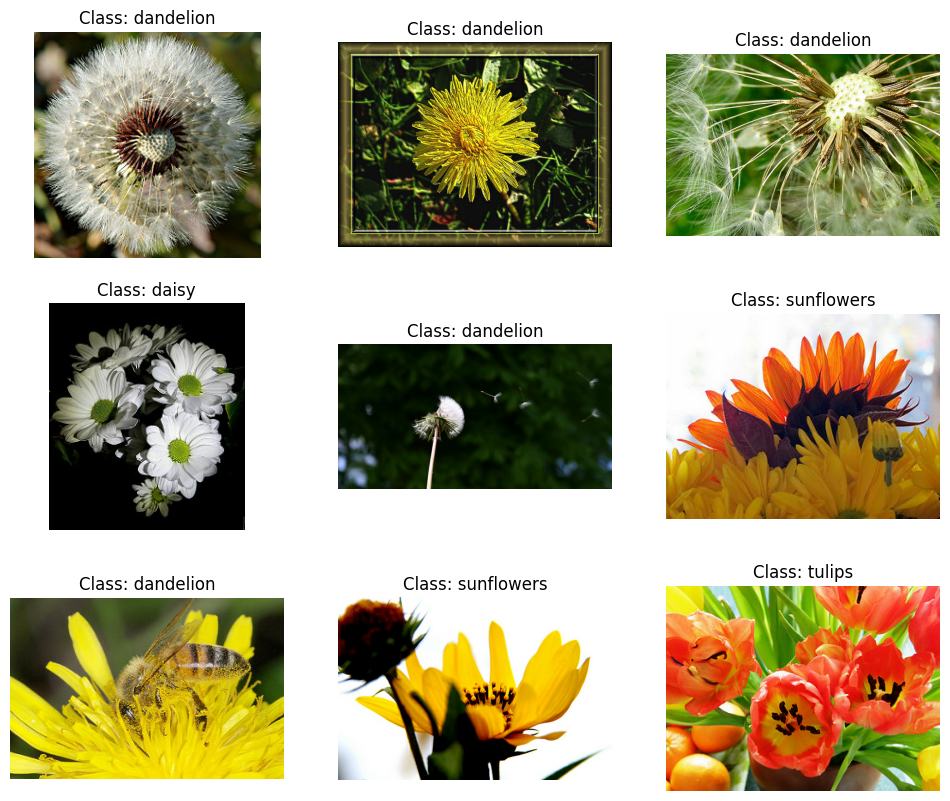

In [9]:
plt.figure(figsize=(12, 10))
index=0
for image, label in train_set_raw.take(9):
    index+=1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title("Class: {}".format(class_names[label.numpy()]))
    plt.axis("off") 
    
plt.show()

In [10]:
# Basic Preprocessing the data
def preprocess(image, label):
    resized_image = tf.image.resize(image, [224, 224])  
    final_image= keras.applications.xception.preprocess_input(resized_image)
    return final_image, label

In [11]:
# Slightly fancier preprocessing the data

from functools import partial

def central_crop(image):
    shape = tf.shape(image)
    min_dim = tf.reduce_min([shape[0], shape[1]])
    top_crop = (shape[0] - min_dim) // 4
    bottom_crop = shape[0] - top_crop
    left_crop = (shape[1] - min_dim) // 4
    right_crop = shape[1] - left_crop
    return image[top_crop:bottom_crop, left_crop:right_crop]

def random_crop(image):
    shape = tf.shape(image)
    min_dim = tf.reduce_min([shape[0], shape[1]]) * 90 // 100
    return tf.image.random_crop(image, [min_dim, min_dim, 3])

def preprocess(image, label, randomize=False):
    if randomize:
        cropped_image = random_crop(image)
        cropped_image = tf.image.random_flip_left_right(cropped_image)
    else:
        cropped_image = central_crop(image)
    resized_image = tf.image.resize(cropped_image, [224, 224])
    final_image = keras.applications.xception.preprocess_input(resized_image)
    return final_image, label

batch_size = 32
train_set = train_set_raw.shuffle(1000).repeat()
train_set = train_set.map(partial(preprocess, randomize=True)).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)



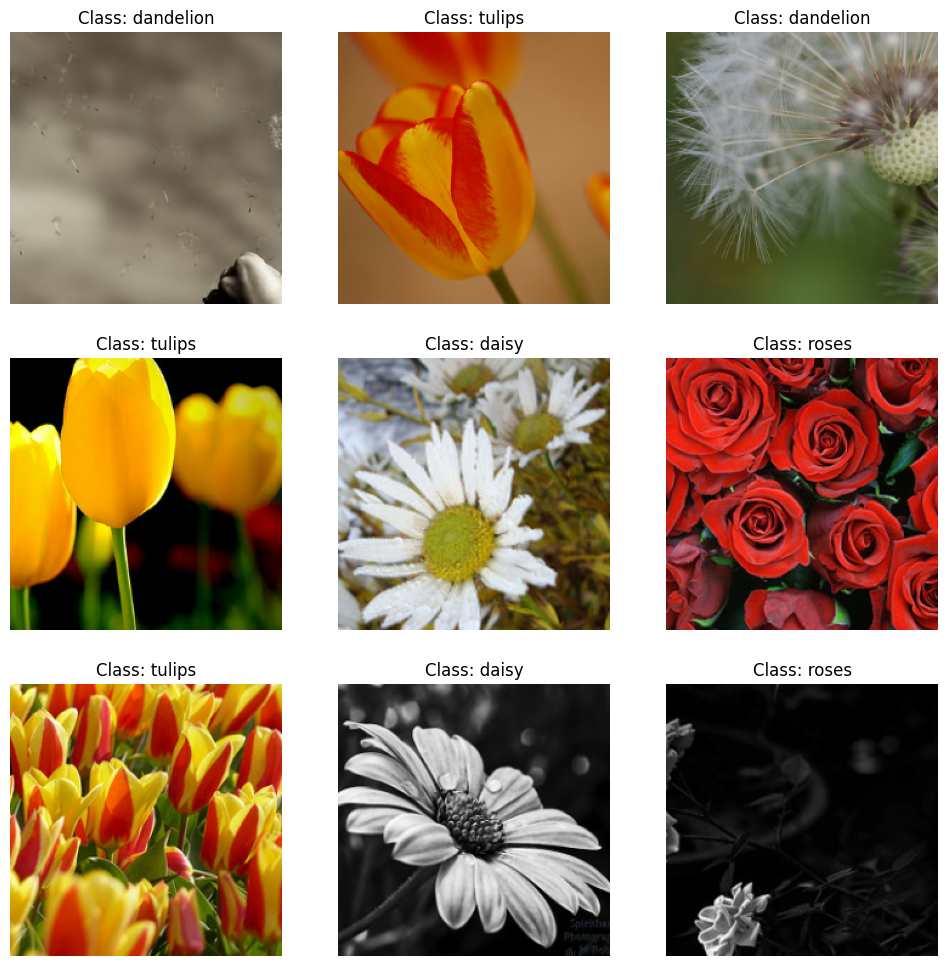

In [12]:


plt.figure(figsize=(12, 12))
for X_batch, y_batch in train_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow(X_batch[index] / 2 + 0.5)
        plt.title("Class: {}".format(class_names[y_batch[index]]))
        plt.axis("off")

plt.show()



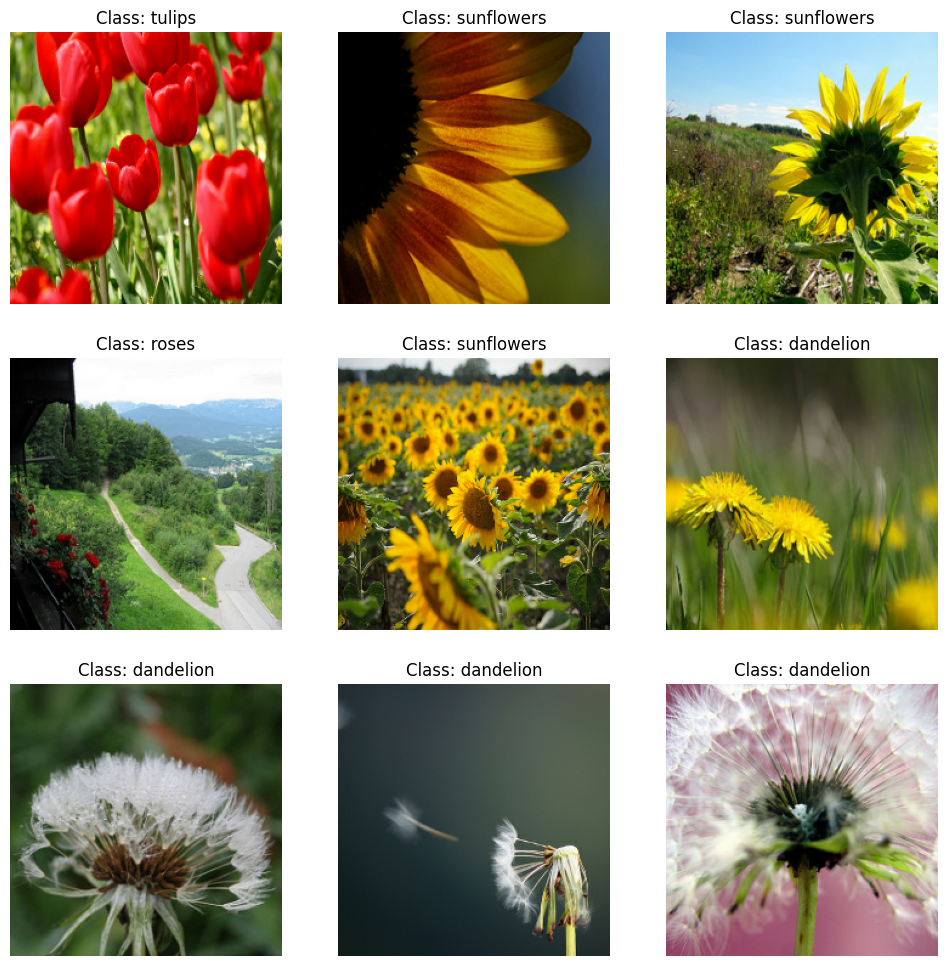

In [13]:
plt.figure(figsize=(12, 12))
for X_batch, y_batch in test_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow(X_batch[index] / 2 + 0.5)
        plt.title("Class: {}".format(class_names[y_batch[index]]))
        plt.axis("off")

plt.show()


In [14]:
base_model = keras.applications.xception.Xception(weights="imagenet", include_top=False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
model= keras.models.Model(inputs= base_model.input, outputs= output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
# Freeze the base model and only train the top layers
# Main goal is to train the top layers to learn the new dataset and then unfreeze the base model and train the whole model with a lower learning rate

for layer in base_model.layers:
    layer.trainable = False

optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9, decay=0.01)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set,
                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=5)



Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 198ms/step - accuracy: 0.7958 - loss: 1.2356 - val_accuracy: 0.8254 - val_loss: 1.3816
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.8725 - loss: 0.8921 - val_accuracy: 0.8254 - val_loss: 1.4910
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step - accuracy: 0.8979 - loss: 0.6528 - val_accuracy: 0.8603 - val_loss: 1.0460
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.9219 - loss: 0.4347 - val_accuracy: 0.8438 - val_loss: 1.3034
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.9186 - loss: 0.4702 - val_accuracy: 0.8051 - val_loss: 1.9858


In [16]:

# Unfreeze the base model and train the whole model with a lower learning rate
# The outcome will be better than training the whole model from the start because the top layers have already learned to extract features from the new dataset and now the base model can fine-tune those features to better fit the new dataset
for layer in base_model.layers:
    layer.trainable = True

optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
                                 nesterov=True, decay=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set,
                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=40)

Epoch 1/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 86s 542ms/step - accuracy: 0.8834 - loss: 0.3921 - val_accuracy: 0.8732 - val_loss: 0.5608
Epoch 2/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 468ms/step - accuracy: 0.9553 - loss: 0.1428 - val_accuracy: 0.8640 - val_loss: 0.4327
Epoch 3/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 470ms/step - accuracy: 0.9742 - loss: 0.0797 - val_accuracy: 0.9062 - val_loss: 0.3036
Epoch 4/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 470ms/step - accuracy: 0.9778 - loss: 0.0660 - val_accuracy: 0.9044 - val_loss: 0.2722
Epoch 5/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 471ms/step - accuracy: 0.9862 - loss: 0.0388 - val_accuracy: 0.9191 - val_loss: 0.3066
Epoch 6/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 470ms/step - accuracy: 0.9891 - loss: 0.0314 - val_accuracy: 0.9081 - val_loss: 0.3334
Epoch 7/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 470ms/step - accuracy: 0.9876 - loss: 0.0414 - val_accuracy: 0.9265 - val_loss: 0.3272
Epoch 8/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 470ms/step - accuracy: 0.9924 - loss: 0.0281 - val_accu

In [17]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_set, steps=int(0.15 * dataset_size / batch_size))
print("Test accuracy: {:.2f}%".format(test_acc * 100))

17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 949ms/step - accuracy: 0.9510 - loss: 0.2792
Test accuracy: 95.10%


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
